#### Before deploying any data into the ml algorithms we need to make data suitable for ml model to process so converting the raw data into the suitable form to pass into ml algorithm is called Feature Engineering.

#### Feature means columns in datasets.

### Feature Engineering
       -Feature Transformation
            * Missing Value imputation
            * Handling Categorical Features
            * Outlier Detection
            * Feature Scaling
       - Feature Construction
       - Feature Selection
       - Feature Extraction
    


# 1. Feature Scaling
#### Feature scaling is a technique to standardize the independent features              present in the data in a fixed range.
           a.) Standardization (z_score Normalization)

               xi= (xi-x mean)/S.D
                After standardization mean will be 0 and S.D will be 1.

In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [42]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/Telco_customer_churn.csv',usecols=['Tenure Months','Monthly Charges','Total Charges','Churn Value'])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tenure Months    7043 non-null   int64  
 1   Monthly Charges  7043 non-null   float64
 2   Total Charges    7043 non-null   object 
 3   Churn Value      7043 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 220.2+ KB


In [44]:
df["Total Charges"] = df["Total Charges"].str.strip()
df.loc[df["Total Charges"] == "", "Total Charges"] = np.nan

df["Total Charges"] = df["Total Charges"].replace(r"^\s*$", np.nan, regex=True)

In [59]:
df.loc[df["Total Charges"].isnull()]

,Tenure Months,Monthly Charges,Total Charges,Churn Value
2234,0,52.55,NaN,0
2438,0,20.25,NaN,0
2568,0,80.85,NaN,0
2667,0,25.75,NaN,0
2856,0,56.05,NaN,0
4331,0,19.85,NaN,0
4687,0,25.35,NaN,0
5104,0,20.00,NaN,0
5719,0,19.70,NaN,0
6772,0,73.35,NaN,0


In [60]:
df.dropna(inplace=True)

In [61]:
df["Total Charges"] = df["Total Charges"].astype(float)

In [62]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test= train_test_split(df.drop('Churn Value',axis=1),
                                                 df['Churn Value'],
                                                 test_size=0.3,
                                                 random_state=0)

In [63]:
x_train

,Tenure Months,Monthly Charges,Total Charges
6813,72,25.75,1864.20
789,23,48.35,1067.15
561,3,75.25,242.00
298,2,95.15,196.90
5156,60,104.70,6333.80
...,...,...,...
4938,72,65.70,4575.35
3269,17,90.95,1612.20
1653,1,35.05,35.05
2610,13,20.00,268.45


In [64]:
x_train.shape , x_test.shape

((4922, 3), (2110, 3))

In [65]:
# from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [66]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [67]:
x_test_scaled

,Tenure Months,Monthly Charges,Total Charges
0,-1.075059,-1.482111,-0.948610
1,1.630113,1.744182,2.831407
2,-0.993084,-0.334838,-0.801066
3,-1.279996,-0.470786,-0.978350
4,-0.706172,-0.450891,-0.693853
...,...,...,...
2105,-0.952097,-1.457243,-0.918624
2106,1.507151,-1.329583,-0.268657
2107,0.769377,0.159220,0.626592
2108,1.589126,1.198729,2.134154


In [68]:
np.round(x_train_scaled.describe(),1)

,Tenure Months,Monthly Charges,Total Charges
count,4922.0,4922.0,4922.0
mean,-0.0,-0.0,0.0
std,1.0,1.0,1.0
min,-1.3,-1.5,-1.0
25%,-1.0,-1.0,-0.8
50%,-0.2,0.2,-0.4
75%,0.9,0.8,0.6
max,1.6,1.8,2.9


Text(0.5, 1.0, 'After scaling')

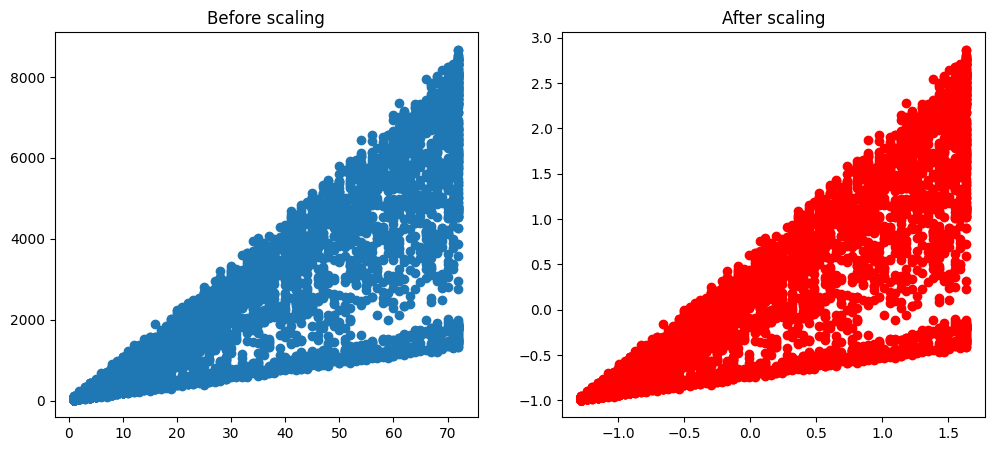

In [71]:
fig,(ax1, ax2)=plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Tenure Months'],x_train['Total Charges'])
ax1.set_title("Before scaling")
ax2.scatter(x_train_scaled['Tenure Months'],x_train_scaled['Total Charges'],color='red')

ax2.set_title("After scaling")

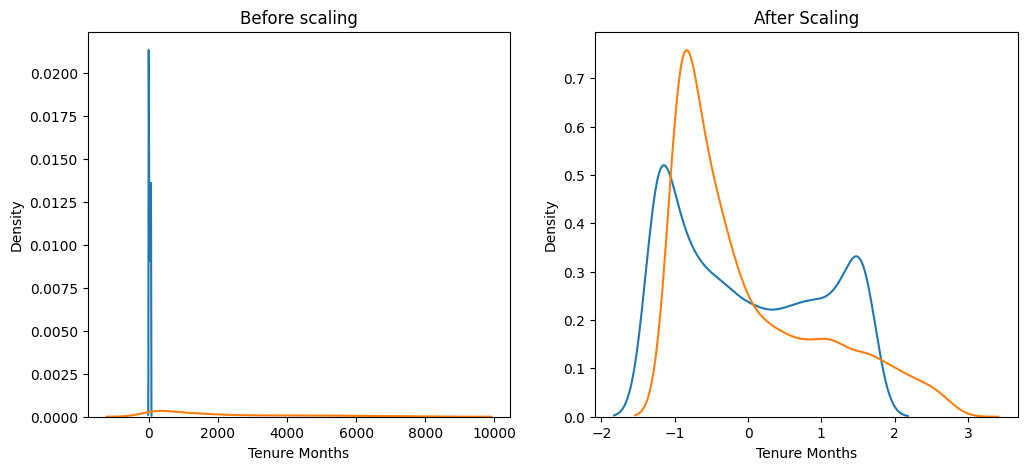

In [72]:
fig,(ax1, ax2)=plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before scaling')
sns.kdeplot(x_train['Tenure Months'],ax=ax1)
sns.kdeplot(x_train['Total Charges'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Tenure Months'],ax=ax2)
sns.kdeplot(x_train_scaled['Total Charges'],ax=ax2)
plt.show()


#### Here it is the pdf of both coulumns before and after scaling, here we cant compare before scaling but after scaling we can compare between them and analyse easily.

#### Individually both columns doesnt change in their distribution, distribution is retained properly before and after scaling

In [73]:
from sklearn.linear_model import LogisticRegression


In [74]:
lr= LogisticRegression()
lr_scaled= LogisticRegression()

In [76]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [77]:
y_pred =lr.predict(x_test)
y_pred_scaled =lr_scaled.predict(x_test_scaled)


In [78]:
from sklearn.metrics import accuracy_score

In [79]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))


Actual 0.7805687203791469
Scaled 0.7805687203791469


In [80]:
from sklearn.tree import DecisionTreeClassifier

In [81]:
dt = DecisionTreeClassifier()
dt_scaled= DecisionTreeClassifier()

In [82]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [83]:
y_pred =dt.predict(x_test)
y_pred_scaled =dt_scaled.predict(x_test_scaled)

In [84]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.7170616113744076
Scaled 0.7137440758293839


#### Standardization is used surely on :
        - K-Means
        - K-Nearest-Neighbours
        - Principal Component Analysis(PCA)
        - Artificial Neural Network
        - Gradient Descent 
          